# Import dependancies

In [1]:
import pandas as pd
import numpy as np
import optuna
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load Data

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")

print(f"Train df shape: {train.shape}")
print(f"Test df shape:  {test.shape}")

target_col = "health_condition"

train.head()

Train df shape: (690088, 15)
Test df shape:  (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


# Exploratory data analysis

## Target Distribution

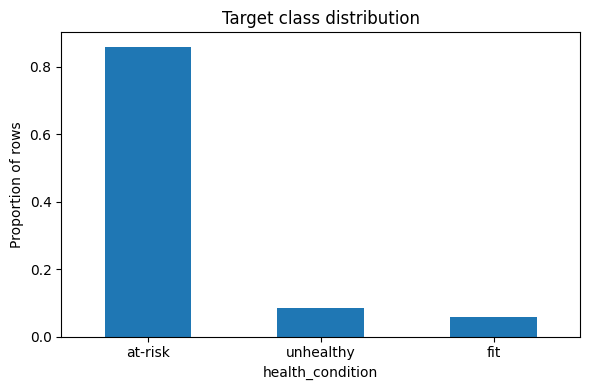

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
train[target_col].value_counts(normalize=True).plot(kind="bar", ax=ax)
ax.set_title("Target class distribution")
ax.set_ylabel("Proportion of rows")
ax.set_xlabel(target_col)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Categorical features vs target

In [4]:
cat_columns = train.select_dtypes(include='object').columns.drop(target_col).tolist()

for col in cat_columns:
    print(f'-------------------{col}--------------------')
    print(pd.crosstab(train[col], train[target_col], normalize="index").round(4))
    print('\n\n')

-------------------diet_type--------------------
health_condition  at-risk     fit  unhealthy
diet_type                                   
balanced           0.8514  0.0612     0.0874
non-veg            0.8678  0.0516     0.0806
veg                0.8567  0.0604     0.0830



-------------------stress_level--------------------
health_condition  at-risk     fit  unhealthy
stress_level                                
high               0.7178  0.0035     0.2787
low                0.7967  0.2006     0.0028
medium             0.9939  0.0030     0.0031



-------------------sleep_quality--------------------
health_condition  at-risk     fit  unhealthy
sleep_quality                               
average            0.8593  0.0573     0.0834
good               0.8878  0.0817     0.0305
poor               0.8296  0.0346     0.1358



-------------------physical_activity_level--------------------
health_condition         at-risk     fit  unhealthy
physical_activity_level                        

# Feature engineering

## Clean datas

In [5]:
for frame in (train, test):
    frame["activity_score"]        = frame["step_count"] * frame["exercise_duration"]
    frame["sleep_activity_ratio"]  = frame["sleep_duration"] / (frame["exercise_duration"] + 1)
    frame["stress_activity_combo"] = (
        frame["stress_level"].astype(str) + "_" +
        frame["physical_activity_level"].astype(str)
    )

In [6]:
unrelated_columns = ['id', 'diet_type', 'gender']

x_train, y_train = train.drop(columns=unrelated_columns+[target_col], axis=1), train[target_col]
x_test_ids, x_test = test["id"], test.drop(columns=unrelated_columns, axis=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)

(690088, 14)
(295753, 14)
(690088,)


# Missing values

In [7]:
numerics_columns = x_train.select_dtypes(include="number").columns
category_columns = x_train.select_dtypes(include=["object", "category"]).columns

num_imputer = SimpleImputer(strategy="median")
x_train[numerics_columns] = num_imputer.fit_transform(x_train[numerics_columns])
x_test[numerics_columns] = num_imputer.transform(x_test[numerics_columns])

category_imputer = SimpleImputer(strategy="most_frequent")
x_train[category_columns] = category_imputer.fit_transform(x_train[category_columns])
x_test[category_columns] = category_imputer.transform(x_test[category_columns])

print(f"Null values in train df: {x_train.isnull().sum().sum()}")
print(f"Null valyes in test df:  {x_test.isnull().sum().sum()}")

Null values in train df: 0
Null valyes in test df:  0


# Encode category values

In [8]:
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)

for col in category_columns:
    le = LabelEncoder()
    all_rows = pd.concat([x_train[col], x_test[col]]).astype("string")
    le.fit(all_rows)
    x_train[col] = le.transform(x_train[col].astype("string"))
    x_test[col] = le.transform(x_test[col].astype("string"))
x_train.head()
    

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,activity_score,sleep_activity_ratio,stress_activity_combo
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,0,0,2,2,26254.8,0.250962,3
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,0,1,2,493560.9,0.108644,5
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,0,2,0,2,541629.6,0.135294,0
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,0,0,0,1,429722.6,0.077176,0
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,2,0,2,2,302864.0,0.153830,15


# Hyperparameter tuning with Optuna

In [ ]:
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int(  "n_estimators",      1000,  3000),
        "learning_rate":     trial.suggest_float( "learning_rate",     0.01, 0.2,  log=True),
        "num_leaves":        trial.suggest_int(   "num_leaves",        40,   500),
        "max_depth":         trial.suggest_int(   "max_depth",         7,    10),
        "min_child_samples": trial.suggest_int(   "min_child_samples", 10,   80),
        "subsample":         trial.suggest_float( "subsample",         0.7,  1.0),
        "colsample_bytree":  trial.suggest_float( "colsample_bytree",  0.7,  1.0),
        "reg_alpha":         trial.suggest_float( "reg_alpha",         1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float( "reg_lambda",        1e-8, 10.0, log=True),
        "min_split_gain":    trial.suggest_float( "min_split_gain",    0.0,  1.0),
        "min_child_weight":  trial.suggest_float( "min_child_weight",  1e-3, 10.0, log=True),
        "random_state": 42,
        "verbose":      -1,
        "n_jobs":       4,

        'device': 'gpu',          # Enable GPU
        'gpu_platform_id': 0,     # Select platform (0 is default)
        'gpu_device_id': 0,       # Select specific GPU
        'max_bin': 63,            # Recommended for better GPU performance
        'gpu_use_dp': False       # Use single precision for speed
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []

    for fold_i, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
        start = time.time()
        X_tr, X_va = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]

        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr, sample_weight=weights)

        preds = model.predict(X_va)
        fold_scores.append(balanced_accuracy_score(y_va, preds))
        print(f"  fold {fold_i} done in {time.time()-start:.1f}s")

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize", study_name="lgbm_student_health")
study.optimize(objective, n_trials=30, n_jobs=4, show_progress_bar=True)

print(f"\nbest CV balanced accuracy : {study.best_value:.4f}")
print(f"best parameters           : {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen

  fold 0 done in 104.4s
  fold 1 done in 90.2s
  fold 2 done in 101.4s
  fold 0 done in 315.1s
  fold 0 done in 155.8s
  fold 0 done in 567.8s
  fold 1 done in 174.3s
  fold 1 done in 313.8s
  fold 2 done in 150.0s
  fold 2 done in 301.7s
  fold 1 done in 575.7s
  fold 0 done in 434.0s
  fold 0 done in 1357.1s


# Train final LightGBM with best parameters

In [ ]:
best_params = study.best_params.copy()
best_params.update({"random_state": 42, "verbose": -1, "n_jobs": -1})

final_model = LGBMClassifier(**best_params)
sample_weights = compute_sample_weight(class_weight="balanced", y=y)
final_model.fit(x_train, y_train, sample_weight=sample_weights)

# quick sanity — OOF-style single split score
X_tr, X_va, y_tr, y_va = train_test_split(x_train, y_train, test_size=0.2,
                                           random_state=42, stratify=y)
w_tr = compute_sample_weight(class_weight="balanced", y=y_tr)
_m = LGBMClassifier(**best_params)
_m.fit(X_tr, y_tr, sample_weight=w_tr)
print("Val balanced accuracy:", balanced_accuracy_score(y_va, _m.predict(X_va)))

In [ ]:
best_params = {
    "n_estimators": 1130,
    "learning_rate": 0.039473000534460304,
    "num_leaves": 47,
    "max_depth": 9,
    "min_child_samples": 67,
    "subsample": 0.8751250127836131,
    "colsample_bytree": 0.8258217201241972,
    "reg_alpha": 9.952843609134993,
    "reg_lambda": 2.6888848305259572e-05,
    "min_split_gain": 0.8494984140714185,
    "min_child_weight": 1.0790643236219504,
    "random_state": 42,
    "verbose": -1,
    "n_jobs": -1,

    'device': 'gpu',          # Enable GPU
    'gpu_platform_id': 0,     # Select platform (0 is default)
    'gpu_device_id': 0,       # Select specific GPU
    'max_bin': 63,            # Recommended for better GPU performance
    # 'gpu_use_dp': False       # Use single precision for speed
}

In [ ]:
weights = compute_sample_weight(class_weight="balanced", y=y_train)

model = LGBMClassifier(**best_params)

model.fit(x_train, y_train, sample_weight=weights)

In [ ]:
importances = pd.Series(model.feature_importances_,
                         index=x_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 15 feature importances (LightGBM)")
plt.tight_layout()
plt.show()

# Predict on test set and build submission

In [ ]:
test_preds_encoded = model.predict(x_test)
test_preds         = target_encoder.inverse_transform(test_preds_encoded)

submission = pd.DataFrame({"id": x_test_ids, target_col: test_preds})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved —", len(submission), "rows")
submission.head()